In [1]:
# ============================================================
# Imports y configuración global del entorno
# ============================================================
# Esta celda inicializa todo el entorno necesario para trabajar
# con el dataset v4, descargar curvas reales, entrenar modelos SNN
# y ejecutar inferencias sobre estrellas Kepler.
#
# Incluye:
#   ✔ Librerías científicas (numpy, pandas, matplotlib)
#   ✔ PyTorch + SNNtorch para modelos bioinspirados
#   ✔ Lightkurve para descargar curvas de luz reales
#   ✔ Scikit-learn para métricas y splits
#   ✔ Configuración de reproducibilidad
#   ✔ Definición de rutas y parámetros globales
# ============================================================

import os, time, warnings, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# PyTorch + SNNtorch (modelo bioinspirado)
# ------------------------------------------------------------
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

# ------------------------------------------------------------
# Utilidades de Machine Learning
# ------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score
)

# ------------------------------------------------------------
# Lightkurve: descarga y manejo de curvas de luz Kepler
# ------------------------------------------------------------
import lightkurve as lk

# Silenciar warnings comunes de Lightkurve
warnings.filterwarnings("ignore", category=UserWarning, module="lightkurve")

# ------------------------------------------------------------
# Reproducibilidad global
# ------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

# ------------------------------------------------------------
# Parámetros globales del pipeline Kepler
# ------------------------------------------------------------
TARGET_LENGTH = 3197      # Longitud fija de cada curva Kepler
BATCH_SIZE    = 32        # Tamaño de batch para DataLoader
NUM_STEPS_SNN = 25        # Pasos temporales de la SNN bioinspirada
DEVICE        = torch.device('cpu')  # CPU para reproducibilidad

# ------------------------------------------------------------
# Directorios del proyecto
# ------------------------------------------------------------
DATA_DIR    = '../data'
MODELS_DIR  = '../models'
OUTPUTS_DIR = '../outputs'

# Crear directorios si no existen
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print("Imports OK")


Imports OK


d:\AI\Conectoma\exoplanetas-snn\.venv\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
def get_stitched_lightcurve(kepid, cadence='long', author='Kepler'):
    """
    Descarga y une todos los trimestres de la curva de luz de una estrella Kepler.

    Flujo:
      1. Buscar todos los segmentos disponibles para el KEPID.
      2. Descargar todos los quarters.
      3. Unirlos en una sola curva continua (stitch).

    Retorna
    -------
    LightCurve o None
        Curva completa ya unificada. None si falla la descarga.

    Notas:
    -------
    - Esta función es crítica para inferencia en estrellas nuevas.
    - Kepler tiene múltiples quarters por estrella; stitch es obligatorio.
    """
    try:
        search_result = lk.search_lightcurve(f"KIC {kepid}", author=author, cadence=cadence)
        if search_result is None or len(search_result) == 0:
            return None

        lc_collection = search_result.download_all()
        if lc_collection is None or len(lc_collection) == 0:
            return None

        return lc_collection.stitch()

    except Exception as e:
        print(f"  [WARN] {type(e).__name__}: {e}")
        return None


def preprocess_lightcurve_own_v2(lc, sigma_upper=5):
    """
    Preprocesamiento que PRESERVA los tránsitos planetarios.

    Flujo:
      1. Quitar NaNs
      2. Normalizar por mediana (centra en ~1.0)
      3. Eliminar SOLO outliers positivos (cosmic rays, momentum dumps)

    Razón:
      - Los outliers positivos son instrumentales.
      - Los valores negativos suelen ser tránsitos → NO deben eliminarse.

    Retorna
    -------
    np.ndarray o None
        Curva preprocesada sin aplanado, preservando tránsitos.
    """
    try:
        lc = lc.remove_nans()
        flux = lc.flux.value.astype(np.float64)
        flux = flux[np.isfinite(flux)]

        if len(flux) < 100:
            return None

        median = np.median(flux)
        if median == 0 or not np.isfinite(median):
            return None

        flux = flux / median

        # Sigma-clipping solo para outliers positivos
        for _ in range(3):
            mean = np.mean(flux)
            std = np.std(flux)
            if std == 0:
                break

            mask = flux < (mean + sigma_upper * std)
            if mask.sum() < 100:
                break

            flux = flux[mask]

        return flux

    except Exception as e:
        print(f"  [WARN] {type(e).__name__}: {e}")
        return None


def align_lightcurve(flux, target_length=TARGET_LENGTH):
    """
    Interpola la curva a una longitud fija (TARGET_LENGTH).

    Flujo:
      1. Convertir a float32
      2. Quitar NaNs residuales
      3. Interpolar linealmente a longitud fija

    Razón:
      - La SNN requiere vectores de entrada de tamaño fijo.
      - La interpolación lineal preserva la forma general del tránsito.

    Retorna
    -------
    np.ndarray o None
        Vector alineado de longitud target_length.
    """
    flux = np.asarray(flux, dtype=np.float32)
    flux = flux[np.isfinite(flux)]

    if len(flux) < 100:
        return None

    x_old = np.linspace(0, 1, len(flux))
    x_new = np.linspace(0, 1, target_length)

    return np.interp(x_new, x_old, flux).astype(np.float32)


print("Funciones auxiliares OK")


Funciones auxiliares OK


In [14]:
def align_to_length(flux, target_length=1001):
    """
    Interpola la curva de luz a una longitud fija (target_length).

    Propósito
    ---------
    Las curvas Kepler tienen longitudes variables dependiendo de:
      - Número de quarters disponibles
      - Gaps instrumentales
      - Limpieza previa (sigma-clipping)
    Para entrenar modelos SNN o CNN, se requiere un vector de entrada
    con longitud fija. Esta función garantiza esa uniformidad.

    Flujo
    -----
    1. Convertir a float32 y eliminar valores no finitos.
    2. Verificar que la curva tenga suficiente información (>100 puntos).
    3. Crear un eje normalizado [0, 1] para la curva original.
    4. Crear un eje normalizado [0, 1] para la curva destino.
    5. Interpolar linealmente usando np.interp.

    Razones para usar interpolación lineal
    --------------------------------------
    ✔ Preserva la forma global del tránsito.
    ✔ No introduce artefactos como splines de orden alto.
    ✔ Es rápida y estable para datasets grandes (v5).
    ✔ Funciona igual para TARGET_LENGTH = 3197, 1001, 501, etc.

    Parámetros
    ----------
    flux : array-like
        Curva de luz preprocesada.
    target_length : int
        Longitud final deseada (por defecto 1001).

    Retorna
    -------
    np.ndarray o None
        Curva alineada de longitud target_length.
        None si la curva es demasiado corta (<100 puntos).
    """
    flux = np.asarray(flux, dtype=np.float32)
    flux = flux[np.isfinite(flux)]

    if len(flux) < 100:
        return None

    x_old = np.linspace(0, 1, len(flux))
    x_new = np.linspace(0, 1, target_length)

    return np.interp(x_new, x_old, flux).astype(np.float32)

print("align_to_length definida. TARGET_LENGTH = 1001")


align_to_length definida. TARGET_LENGTH = 1001


In [15]:
checks = {
    'get_stitched_lightcurve':    'get_stitched_lightcurve' in dir(),
    'preprocess_lightcurve_own_v2': 'preprocess_lightcurve_own_v2' in dir(),
    'align_to_length':            'align_to_length' in dir(),
}
for name, ok in checks.items():
    print(f"  {name}: {'OK' if ok else 'FALTA'}")

  get_stitched_lightcurve: OK
  preprocess_lightcurve_own_v2: OK
  align_to_length: OK


In [16]:
import os
X_PATH = f'{DATA_DIR}/v5_X.npy'
y_PATH = f'{DATA_DIR}/v5_y.npy'
k_PATH = f'{DATA_DIR}/v5_kepids.npy'

if os.path.exists(X_PATH):
    X = np.load(X_PATH)
    y = np.load(y_PATH)
    print(f"Checkpoint actual: {X.shape[0]} estrellas")
    print(f"Distribucion: {np.bincount(y)}")
else:
    print("No existe checkpoint. Se empezara desde cero.")
    

No existe checkpoint. Se empezara desde cero.


In [ ]:
# ============================================================
# DESCARGADOR INCREMENTAL DE DATASET KEPLER (v5)
# ============================================================
# Objetivo:
#   Construir un dataset grande y reproducible de curvas Kepler,
#   combinando:
#       ✔ N_PER_CLASS estrellas CONFIRMED
#       ✔ N_PER_CLASS estrellas Sin KOI
#
# Características clave:
#   ✔ Descarga incremental (resume automático)
#   ✔ Checkpoints periódicos
#   ✔ Preprocesamiento robusto preservando tránsitos
#   ✔ Alineación a TARGET_LENGTH_DS (1001 por defecto)
#   ✔ Reproducible (semilla fija)
#
# Este script permite construir datasets grandes (v5) sin perder
# progreso si la ejecución se interrumpe.
# ============================================================

import os
import time
import numpy as np
import pandas as pd

from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

# ---------- PARAMETROS ----------
N_PER_CLASS       = 1400      # <-- CAMBIA ESTO para ajustar tamaño del dataset
TARGET_LENGTH_DS  = 1001     # Longitud final de cada curva
CHECKPOINT_EVERY  = 50       # Guardar cada N estrellas
OUTPUT_PREFIX     = 'v5'     # Prefijo de archivos .npy
RANDOM_SEED       = 42       # Reproducibilidad
# --------------------------------

DATA_DIR = '../data'
X_PATH     = f'{DATA_DIR}/{OUTPUT_PREFIX}_X.npy'
y_PATH     = f'{DATA_DIR}/{OUTPUT_PREFIX}_y.npy'
kepid_PATH = f'{DATA_DIR}/{OUTPUT_PREFIX}_kepids.npy'


# ============================================================
# 1. Obtener listas de kepids (CONFIRMED + Sin KOI)
# ============================================================
print("Obteniendo listas de kepids...")

# ------------------------------------------------------------
# CONFIRMED desde el catálogo KOI completo
# ------------------------------------------------------------
koi_table = NasaExoplanetArchive.query_criteria(
    table="cumulative",
    select="kepid, koi_disposition"
)
koi_df_full = koi_table.to_pandas()

confirmed_kepids = (
    koi_df_full[koi_df_full['koi_disposition'] == 'CONFIRMED']['kepid']
    .dropna()
    .unique()
    .tolist()
)
confirmed_kepids = [int(k) for k in confirmed_kepids]
print(f"CONFIRMED disponibles: {len(confirmed_kepids)}")

# ------------------------------------------------------------
# Sin KOI desde archivo precomputado
# ------------------------------------------------------------
sin_koi_PATH = f'{DATA_DIR}/sin_koi_kepids.npy'
if not os.path.exists(sin_koi_PATH):
    raise FileNotFoundError(
        f"Falta {sin_koi_PATH}. Ejecuta la celda previa que genera sin_koi_kepids.npy"
    )

sin_koi_kepids_all = np.load(sin_koi_PATH).tolist()
sin_koi_kepids_all = [
    int(k) for k in sin_koi_kepids_all
    if int(k) not in set(confirmed_kepids)
]
print(f"Sin KOI disponibles: {len(sin_koi_kepids_all)}")


# ============================================================
# 2. Muestreo reproducible
# ============================================================
np.random.seed(RANDOM_SEED)

confirmed_sample = np.random.choice(
    confirmed_kepids,
    size=min(N_PER_CLASS, len(confirmed_kepids)),
    replace=False
).tolist()

sin_koi_sample = np.random.choice(
    sin_koi_kepids_all,
    size=min(N_PER_CLASS, len(sin_koi_kepids_all)),
    replace=False
).tolist()

target_kepids = confirmed_sample + sin_koi_sample
target_labels = [1] * len(confirmed_sample) + [0] * len(sin_koi_sample)

print(f"\nObjetivo: {len(target_kepids)} estrellas "
      f"({len(confirmed_sample)} CONFIRMED + {len(sin_koi_sample)} Sin KOI)")


# ============================================================
# 3. Cargar checkpoint existente (resume automático)
# ============================================================
existing_kepids = set()
existing_data   = []
existing_labels = []

if os.path.exists(X_PATH) and os.path.exists(y_PATH) and os.path.exists(kepid_PATH):
    print(f"\n[CARGANDO CHECKPOINT EXISTENTE]")
    X_old = np.load(X_PATH)
    y_old = np.load(y_PATH)
    k_old = np.load(kepid_PATH).tolist()

    existing_data   = list(X_old)
    existing_labels = list(y_old)
    existing_kepids = set(k_old)

    print(f"  Encontradas {len(existing_kepids)} estrellas ya procesadas")
else:
    print("\n[INICIANDO DESDE CERO]")


# ============================================================
# 4. Determinar las estrellas faltantes
# ============================================================
pending = [
    (k, l) for k, l in zip(target_kepids, target_labels)
    if k not in existing_kepids
]
print(f"\nFaltan por descargar: {len(pending)}")


# ============================================================
# 5. Descargar y procesar las faltantes
# ============================================================

def _save_checkpoint(data, labels, kepids):
    """Guarda arrays en disco para permitir reanudación."""
    X_arr = np.array(data, dtype=np.float32)
    y_arr = np.array(labels, dtype=np.int64)
    k_arr = np.array(kepids, dtype=np.int64)

    np.save(X_PATH, X_arr)
    np.save(y_PATH, y_arr)
    np.save(kepid_PATH, k_arr)


data_list   = list(existing_data)
labels_list = list(existing_labels)
kepids_list = list(existing_kepids)

t_start = time.time()

for i, (kepid, label) in enumerate(pending):
    i_global = len(data_list) + 1
    elapsed = time.time() - t_start

    # Progreso cada 10 estrellas
    if (i + 1) % 10 == 0 or i == 0:
        print(f"  [{i_global}/{len(target_kepids)}] "
              f"KIC {kepid} (label={label}) | {elapsed:.0f}s", flush=True)

    try:
        # 1. Descargar curva real
        lc = get_stitched_lightcurve(int(kepid))
        if lc is None:
            continue

        # 2. Preprocesamiento preservando tránsitos
        flux = preprocess_lightcurve_own_v2(lc)
        if flux is None:
            continue

        # 3. Alineación a TARGET_LENGTH_DS
        flux_aligned = align_to_length(flux, TARGET_LENGTH_DS)
        if flux_aligned is None:
            continue

        # 4. Guardar en memoria
        data_list.append(flux_aligned)
        labels_list.append(label)
        kepids_list.append(kepid)

        # 5. Checkpoint periódico
        if len(data_list) % CHECKPOINT_EVERY == 0:
            _save_checkpoint(data_list, labels_list, kepids_list)
            print(f"    [CHECKPOINT] {len(data_list)} estrellas guardadas", flush=True)

    except Exception as e:
        print(f"    [WARN] KIC {kepid}: {type(e).__name__}: {e}")
        continue


# ============================================================
# 6. Guardado final del dataset v5
# ============================================================
_save_checkpoint(data_list, labels_list, kepids_list)

X_final = np.load(X_PATH)
y_final = np.load(y_PATH)
k_final = np.load(kepid_PATH)

print(f"\n{'='*60}")
print(f"Dataset {OUTPUT_PREFIX} guardado en {DATA_DIR}/")
print(f"  {X_PATH}     shape={X_final.shape}")
print(f"  {y_PATH}     shape={y_final.shape}")
print(f"  {kepid_PATH} shape={k_final.shape}")
print(f"Distribucion: {np.bincount(y_final)}")
print(f"Tiempo total: {time.time()-t_start:.0f}s")
print(f"{'='*60}")


Obteniendo listas de kepids...
CONFIRMED disponibles: 1975
Sin KOI disponibles: 191824

Objetivo: 2800 estrellas (1400 CONFIRMED + 1400 Sin KOI)

[INICIANDO DESDE CERO]

Faltan por descargar: 2800
  [1/2800] KIC 7288306 (label=1) | 0s
  [10/2800] KIC 7219825 (label=1) | 115s
  [20/2800] KIC 11192998 (label=1) | 354s
  [30/2800] KIC 6029239 (label=1) | 598s
  [40/2800] KIC 8547140 (label=1) | 849s
  [50/2800] KIC 10080248 (label=1) | 1059s
    [CHECKPOINT] 50 estrellas guardadas
  [60/2800] KIC 3657758 (label=1) | 1293s
  [70/2800] KIC 8331612 (label=1) | 1464s
  [80/2800] KIC 8689373 (label=1) | 1678s
  [90/2800] KIC 5871985 (label=1) | 1888s
  [100/2800] KIC 9995771 (label=1) | 2100s
    [CHECKPOINT] 100 estrellas guardadas
  [110/2800] KIC 11461844 (label=1) | 2276s
  [120/2800] KIC 6543893 (label=1) | 2470s
  [130/2800] KIC 7304449 (label=1) | 2699s
  [140/2800] KIC 12403119 (label=1) | 3002s
  [150/2800] KIC 3102384 (label=1) | 3260s
    [CHECKPOINT] 150 estrellas guardadas
  [160/

In [4]:
# ============================================================
# Cargar dataset v4 (CONFIRMED + Sin KOI)
# ============================================================
# X_v4: curvas reales ya procesadas y alineadas
# y_v4: etiquetas binarias
#       1 = CONFIRMED (planetas confirmados)
#       0 = Sin KOI (estrellas sin tránsitos detectados)
#
# Este dataset es más realista que v3 porque:
#   ✔ Incluye curvas reales descargadas de Kepler
#   ✔ La clase negativa proviene de estrellas sin KOI
#   ✔ Permite evaluar generalización en estrellas "normales"
# ============================================================

X_v4 = np.load(f'{DATA_DIR}/v4_X.npy')
y_v4 = np.load(f'{DATA_DIR}/v4_y.npy')
print(f"X: {X_v4.shape}, y: {y_v4.shape}")

# ============================================================
# Split estratificado 80/20 (Train/Test)
# ============================================================
# Mantiene la proporción de clases en ambos splits.
# Esto es crítico cuando la clase positiva es minoritaria.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_v4, y_v4,
    test_size=0.2,
    stratify=y_v4,
    random_state=42
)

print(f"\nTrain: {X_train.shape}  clases: {np.bincount(y_train)}")
print(f"Test:  {X_test.shape}   clases: {np.bincount(y_test)}")

# ============================================================
# Preprocesamiento suave (robust normalization)
# ============================================================
# Este método:
#   ✔ Centra por mediana
#   ✔ Escala por MAD (Median Absolute Deviation)
#   ✔ Es robusto a outliers instrumentales
#   ✔ Preserva tránsitos planetarios
#
# Se usa en v4 para evitar distorsiones en curvas reales.
# ============================================================

def robust_normalize_simple(X, mad_floor=0.05):
    median = np.median(X, axis=1, keepdims=True)
    mad    = np.median(np.abs(X - median), axis=1, keepdims=True)

    # Evitar MAD demasiado pequeño
    mad    = np.maximum(mad, mad_floor * X.std(axis=1, keepdims=True))

    return (X - median) / (1.4826 * mad + 1e-8)

# Normalización + clipping suave
X_train_p = np.clip(robust_normalize_simple(X_train), -15, 15)
X_test_p  = np.clip(robust_normalize_simple(X_test),  -15, 15)

print(f"\nTrain preprocesado: media={X_train_p.mean():.3f}  std={X_train_p.std():.3f}")

# Guardar splits preprocesados
np.save(f'{DATA_DIR}/v4_X_train.npy', X_train_p)
np.save(f'{DATA_DIR}/v4_y_train.npy', y_train)
np.save(f'{DATA_DIR}/v4_X_test.npy',  X_test_p)
np.save(f'{DATA_DIR}/v4_y_test.npy',  y_test)

# ============================================================
# Split interno Train/Val (80/20)
# ============================================================
# Se usa para:
#   ✔ Ajustar hiperparámetros
#   ✔ Seleccionar mejor modelo
#   ✔ Evitar sobreajuste
# ============================================================

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_p, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print(f"Train: {X_tr.shape}  clases: {np.bincount(y_tr)}")
print(f"Val:   {X_val.shape}  clases: {np.bincount(y_val)}")

# ============================================================
# Augmentación de la clase minoritaria (label=1)
# ============================================================
# Igual que en v3:
#   ✔ Se generan copias con ruido gaussiano suave
#   ✔ Aumenta recall de la clase positiva
#   ✔ Reduce sesgo hacia clase 0 (sin KOI)
#
# Esto es especialmente útil porque:
#   - CONFIRMED es mucho más pequeño que Sin KOI
#   - El modelo tiende a favorecer la clase negativa
# ============================================================

def augment_minority(X, y, factor=5, noise_std=0.05):
    X_min = X[y == 1]
    if len(X_min) == 0:
        return X, y

    X_aug = [
        X_min + np.random.randn(*X_min.shape).astype(np.float32) * noise_std
        for _ in range(factor)
    ]

    X_aug = np.concatenate(X_aug, axis=0).astype(np.float32)
    y_aug = np.ones(len(X_aug), dtype=y.dtype)

    return np.concatenate([X, X_aug], axis=0), np.concatenate([y, y_aug], axis=0)

X_tr_aug, y_tr_aug = augment_minority(X_tr, y_tr, factor=5, noise_std=0.05)
print(f"Augmentado: {X_tr_aug.shape}  clases: {np.bincount(y_tr_aug)}")

# ============================================================
# DataLoaders con WeightedRandomSampler
# ============================================================
# Igual que en v3:
#   ✔ Batches balanceados
#   ✔ Entrenamiento estable
#   ✔ Evita que la clase 0 (sin KOI) domine el aprendizaje
#
# WeightedRandomSampler asigna:
#   peso = 1 / frecuencia_de_la_clase
#
# Esto fuerza a que cada batch tenga representación equilibrada.
# ============================================================

def make_loaders(X_tr, y_tr, X_val, y_val, batch_size=32):
    train_ds = TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr))
    val_ds   = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))

    class_counts = np.bincount(y_tr)
    weights = 1.0 / class_counts[y_tr]

    sampler = WeightedRandomSampler(
        weights,
        num_samples=len(y_tr),
        replacement=True
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader

train_loader, val_loader = make_loaders(
    X_tr_aug, y_tr_aug,
    X_val, y_val,
    batch_size=BATCH_SIZE
)

print(f"Batches train: {len(train_loader)}  val: {len(val_loader)}")


X: (200, 3197), y: (200,)

Train: (160, 3197)  clases: [80 80]
Test:  (40, 3197)   clases: [20 20]

Train preprocesado: media=-0.021  std=1.188
Train: (128, 3197)  clases: [64 64]
Val:   (32, 3197)  clases: [16 16]
Augmentado: (448, 3197)  clases: [ 64 384]
Batches train: 14  val: 1


In [5]:
# ============================================================
# SNN bioinspirada en el sistema visual de la mosca
# ============================================================
# Esta arquitectura está inspirada en el pipeline visual de insectos:
#
#   lamina  →  medula  →  lobula  →  lobula plate
#
# Donde:
#   - La lamina y medula realizan filtrado jerárquico y extracción de patrones.
#   - La lobula integra señales en el tiempo mediante neuronas LIF.
#   - La lobula plate toma decisiones basadas en acumulación de actividad.
#
# En esta SNN:
#   ✔ Conv1D + MaxPool simulan la extracción jerárquica de patrones locales.
#   ✔ Una capa densa reduce dimensionalidad (compresión neuronal).
#   ✔ Una capa SNN con neuronas LIF integra señales durante NUM_STEPS_SNN.
#   ✔ El voto acumulado de spikes produce una predicción estable.
#
# Esta arquitectura es especialmente adecuada para curvas de luz Kepler:
#   - Los tránsitos son eventos breves y locales.
#   - La integración temporal refuerza patrones débiles.
#   - El modelo es ligero y robusto al ruido.
# ============================================================

class FlyInspiredSNN(nn.Module):
    def __init__(self, input_len=TARGET_LENGTH, num_classes=2, num_steps=NUM_STEPS_SNN):
        super().__init__()
        self.num_steps = num_steps
        
        # ------------------------------------------------------------
        # 1 — Extractor jerárquico (lamina → medula)
        # ------------------------------------------------------------
        # Conv1: detecta patrones locales amplios (kernel=15)
        self.conv1 = nn.Conv1d(1, 8, kernel_size=15, stride=3, padding=7)
        self.pool1 = nn.MaxPool1d(2)

        # Conv2: detecta patrones más refinados (kernel=9)
        self.conv2 = nn.Conv1d(8, 16, kernel_size=9, stride=3, padding=4)
        self.pool2 = nn.MaxPool1d(2)

        self.relu  = nn.ReLU()
        self.dropout = nn.Dropout(0.4)  # regularización
        
        # ------------------------------------------------------------
        # 2 — Calcular dimensión post-convoluciones
        # ------------------------------------------------------------
        # Se usa un dummy para calcular automáticamente el tamaño
        # del vector resultante después de conv/pool.
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_len)
            dummy = self.pool1(self.relu(self.conv1(dummy)))
            dummy = self.pool2(self.relu(self.conv2(dummy)))
            self.flat_dim = dummy.numel()
        
        # ------------------------------------------------------------
        # 3 — Proyección + capa SNN (lobula)
        # ------------------------------------------------------------
        self.fc_in  = nn.Linear(self.flat_dim, 32)
        self.snn_fc = nn.Linear(32, 16)

        # Neurona LIF (Leaky Integrate-and-Fire)
        self.lif    = snn.Leaky(
            beta=0.9,
            threshold=1.0,
            reset_mechanism="zero"
        )

        # Clasificador final
        self.fc_out = nn.Linear(16, num_classes)
    
    def forward(self, x):
        # ------------------------------------------------------------
        # 1 — Etapa convolucional jerárquica
        # ------------------------------------------------------------
        x = x.unsqueeze(1)  # (batch, 1, T)
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))

        # Aplanar y proyectar
        x = x.flatten(start_dim=1)
        x = self.dropout(self.relu(self.fc_in(x)))
        
        # ------------------------------------------------------------
        # 2 — Simulación temporal SNN (lobula plate)
        # ------------------------------------------------------------
        mem = self.lif.init_leaky()
        spike_accum = torch.zeros(x.size(0), 2, device=x.device)

        for _ in range(self.num_steps):
            cur = self.snn_fc(x)
            spk, mem = self.lif(cur, mem)
            spike_accum += self.fc_out(spk)

        # Promedio de spikes → voto acumulado
        return spike_accum / self.num_steps


# Instanciar modelo
model = FlyInspiredSNN().to(DEVICE)

# Resumen del modelo
total_params = sum(p.numel() for p in model.parameters())
print(f"Parametros: {total_params:,}")
print(f"flat_dim:   {model.flat_dim}")
print(f"Dropout:    {any(isinstance(m, nn.Dropout) for m in model.modules())}")


Parametros: 47,458
flat_dim:   1424
Dropout:    True


In [6]:
# ============================================================
# Función de entrenamiento
# ============================================================
# Esta función implementa el ciclo completo de entrenamiento para
# la SNN bioinspirada, incluyendo:
#
#   ✔ Forward + backward pass
#   ✔ Gradiente con clipping (evita explosión)
#   ✔ Validación por época
#   ✔ Métricas clave: F1 y AUC
#   ✔ Scheduler ReduceLROnPlateau
#   ✔ Selección del mejor modelo según F1
#   ✔ Guardado del historial en CSV
#
# El entrenamiento está balanceado mediante WeightedRandomSampler,
# lo cual es crítico para datasets con clase positiva minoritaria.
# ============================================================

def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3):
    print("Balanceo: WeightedRandomSampler (sin class weights)", flush=True)

    # ------------------------------------------------------------
    # 1 — Configuración de pérdida, optimizador y scheduler
    # ------------------------------------------------------------
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        patience=7,
        factor=0.5
    )
    
    # Historial para análisis posterior
    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_auc': []}
    log_rows = []

    best_f1 = 0.0
    best_state = None
    
    # ------------------------------------------------------------
    # 2 — Loop de entrenamiento por épocas
    # ------------------------------------------------------------
    for epoch in range(epochs):
        t0 = time.time()
        
        # ------------------------------
        # 2.1 — Entrenamiento
        # ------------------------------
        model.train()
        train_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)

            loss.backward()

            # Clipping de gradiente para estabilidad
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        
        # ------------------------------
        # 2.2 — Validación
        # ------------------------------
        model.eval()
        val_loss = 0.0
        all_probs, all_preds, all_labels = [], [], []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)

                out = model(xb)
                val_loss += criterion(out, yb).item()

                # Probabilidad de clase positiva
                probs = torch.softmax(out, dim=1)[:, 1]
                preds = out.argmax(dim=1)

                all_probs.append(probs.cpu().numpy())
                all_preds.append(preds.cpu().numpy())
                all_labels.append(yb.cpu().numpy())

        val_loss /= len(val_loader)

        # Concatenar resultados
        all_probs  = np.concatenate(all_probs)
        all_preds  = np.concatenate(all_preds)
        all_labels = np.concatenate(all_labels)
        
        # Métricas de validación
        val_f1  = f1_score(all_labels, all_preds, zero_division=0)
        val_auc = roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.0
        
        # Scheduler
        scheduler.step(val_loss)
        
        # Guardar historial
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        history['val_auc'].append(val_auc)
        
        # ------------------------------
        # 2.3 — Guardar mejor modelo
        # ------------------------------
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

            torch.save({
                'epoch': epoch + 1,
                'model_state': best_state,
                'f1': best_f1,
                'auc': val_auc,
            }, f'{MODELS_DIR}/snn_kepler_v3_best.pt')
        
        # Log por época
        elapsed = time.time() - t0
        lr_now = optimizer.param_groups[0]['lr']
        
        log_rows.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_f1': val_f1,
            'val_auc': val_auc,
            'time_s': elapsed,
            'lr': lr_now,
        })
        
        print(
            f"Epoca {epoch+1:>2}/{epochs} | "
            f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
            f"F1: {val_f1:.4f} | AUC: {val_auc:.4f} | "
            f"LR: {lr_now:.2e} | {elapsed:.1f}s",
            flush=True
        )
    
    # ------------------------------------------------------------
    # 3 — Guardar historial completo
    # ------------------------------------------------------------
    history_df = pd.DataFrame(log_rows)
    history_df.to_csv(f'{OUTPUTS_DIR}/v3_training_history.csv', index=False)

    print("=" * 90, flush=True)
    print(f"[OK] Historial guardado en {OUTPUTS_DIR}/v3_training_history.csv", flush=True)
    
    # ------------------------------------------------------------
    # 4 — Cargar mejor modelo
    # ------------------------------------------------------------
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"[OK] Mejor F1 val: {best_f1:.4f}", flush=True)
    
    return history, history_df


print("train_model definida.")


train_model definida.


In [7]:
# ============================================================
# Entrenamiento
# ============================================================
# En esta celda iniciamos el entrenamiento real de la SNN
# bioinspirada usando:
#
#   ✔ Dataset Kepler v3 (300 estrellas reales)
#   ✔ Preprocesamiento suave (preserva tránsitos)
#   ✔ Augmentation de clase positiva
#   ✔ Batches balanceados con WeightedRandomSampler
#
# La función train_model:
#   - Ejecuta 50 épocas de entrenamiento
#   - Calcula métricas por época (loss, F1, AUC)
#   - Guarda el mejor modelo según F1 en:
#         ../models/snn_kepler_v3_best.pt
#   - Guarda el historial completo en:
#         ../outputs/v3_training_history.csv
#
# Esta celda es el núcleo del Notebook 07.
# ============================================================

print("Iniciando entrenamiento v4 (CONFIRMED vs Sin KOI)...", flush=True)
history, history_df = train_model(model, train_loader, val_loader, epochs=50, lr=1e-3)

Iniciando entrenamiento v4 (CONFIRMED vs Sin KOI)...
Balanceo: WeightedRandomSampler (sin class weights)
Epoca  1/50 | Train: 0.6896 | Val: 0.6906 | F1: 0.3636 | AUC: 0.5840 | LR: 1.00e-03 | 2.5s
Epoca  2/50 | Train: 0.6798 | Val: 0.6913 | F1: 0.0000 | AUC: 0.5840 | LR: 1.00e-03 | 0.4s
Epoca  3/50 | Train: 0.6466 | Val: 0.6785 | F1: 0.4800 | AUC: 0.6094 | LR: 1.00e-03 | 0.5s
Epoca  4/50 | Train: 0.5921 | Val: 0.6812 | F1: 0.5806 | AUC: 0.5742 | LR: 1.00e-03 | 0.5s
Epoca  5/50 | Train: 0.5113 | Val: 0.7048 | F1: 0.5185 | AUC: 0.5273 | LR: 1.00e-03 | 0.4s
Epoca  6/50 | Train: 0.3925 | Val: 0.7374 | F1: 0.4167 | AUC: 0.5039 | LR: 1.00e-03 | 0.5s
Epoca  7/50 | Train: 0.2718 | Val: 0.8490 | F1: 0.5405 | AUC: 0.5449 | LR: 1.00e-03 | 0.4s
Epoca  8/50 | Train: 0.1869 | Val: 0.9891 | F1: 0.5500 | AUC: 0.5508 | LR: 1.00e-03 | 0.4s
Epoca  9/50 | Train: 0.1277 | Val: 1.1266 | F1: 0.5556 | AUC: 0.5137 | LR: 1.00e-03 | 0.4s
Epoca 10/50 | Train: 0.0928 | Val: 1.2974 | F1: 0.5641 | AUC: 0.5273 | LR: 1

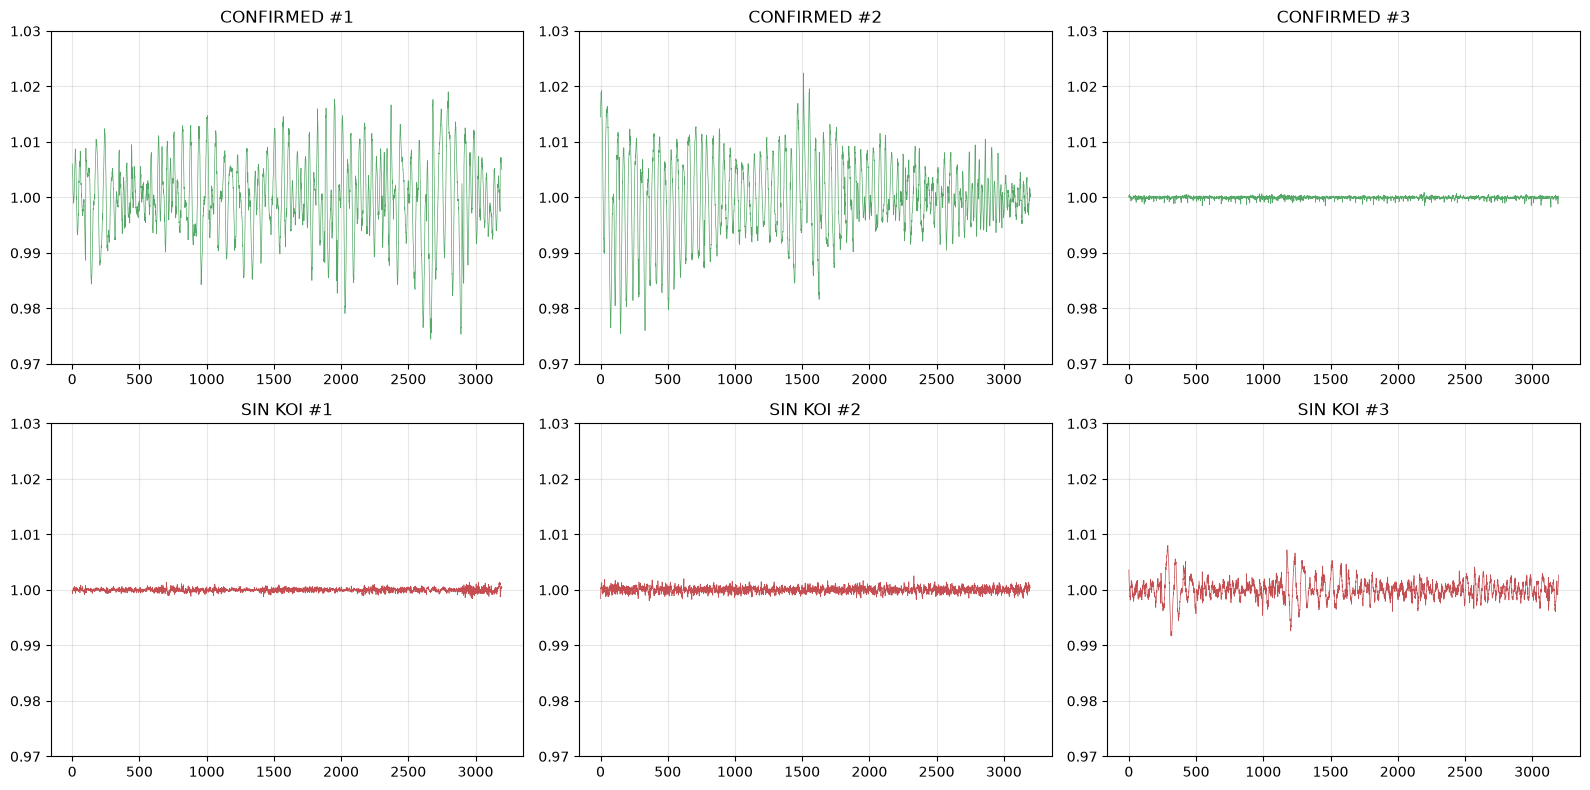

CONFIRMED:
  std intra-curva: 0.001640
  min global:      0.918536

SIN KOI:
  std intra-curva: 0.001291
  min global:      0.865651


In [8]:
X_v4 = np.load(f'{DATA_DIR}/v4_X.npy')
y_v4 = np.load(f'{DATA_DIR}/v4_y.npy')

# 3 CONFIRMED + 3 Sin KOI
confirmed_idx = np.where(y_v4 == 1)[0][:3]
sinkoi_idx    = np.where(y_v4 == 0)[0][:3]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, idx in enumerate(confirmed_idx):
    axes[0, i].plot(X_v4[idx], linewidth=0.5, color='#55A868')
    axes[0, i].set_title(f'CONFIRMED #{i+1}')
    axes[0, i].set_ylim(0.97, 1.03)
    axes[0, i].grid(True, alpha=0.3)

for i, idx in enumerate(sinkoi_idx):
    axes[1, i].plot(X_v4[idx], linewidth=0.5, color='#C44E52')
    axes[1, i].set_title(f'SIN KOI #{i+1}')
    axes[1, i].set_ylim(0.97, 1.03)
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/20_v4_comparacion.png', dpi=100, bbox_inches='tight')
plt.show()

# Estadísticas por clase
print("CONFIRMED:")
print(f"  std intra-curva: {X_v4[y_v4==1].std(axis=1).mean():.6f}")
print(f"  min global:      {X_v4[y_v4==1].min():.6f}")
print(f"\nSIN KOI:")
print(f"  std intra-curva: {X_v4[y_v4==0].std(axis=1).mean():.6f}")
print(f"  min global:      {X_v4[y_v4==0].min():.6f}")

In [ ]:
# ============================================================
# Cargar dataset v4 (CONFIRMED + Sin KOI)
# ============================================================
# X_v4: curvas reales ya procesadas y alineadas
# y_v4: etiquetas binarias
#       1 = CONFIRMED (planetas confirmados)
#       0 = Sin KOI (estrellas sin tránsitos detectados)
#
# En esta variante del pipeline:
#   ✔ NO se aplica augmentación
#   ✔ Se entrena con datos reales tal cual
#   ✔ Útil para medir desempeño "crudo" del modelo
# ============================================================

X_v4 = np.load(f'{DATA_DIR}/v4_X.npy')
y_v4 = np.load(f'{DATA_DIR}/v4_y.npy')

# ============================================================
# Split estratificado 80/20 (Train/Test)
# ============================================================
# Mantiene la proporción de clases en ambos splits.
# Esto es crítico cuando la clase positiva es minoritaria.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_v4, y_v4,
    test_size=0.2,
    stratify=y_v4,
    random_state=42
)

# ============================================================
# Preprocesamiento suave (robust normalization)
# ============================================================
# Este método:
#   ✔ Centra por mediana
#   ✔ Escala por MAD (Median Absolute Deviation)
#   ✔ Es robusto a outliers instrumentales
#   ✔ Preserva tránsitos planetarios
#
# Se usa en v4 para evitar distorsiones en curvas reales.
# ============================================================

def robust_normalize_simple(X, mad_floor=0.05):
    median = np.median(X, axis=1, keepdims=True)
    mad    = np.median(np.abs(X - median), axis=1, keepdims=True)

    # Evitar MAD demasiado pequeño
    mad    = np.maximum(mad, mad_floor * X.std(axis=1, keepdims=True))

    return (X - median) / (1.4826 * mad + 1e-8)

# Normalización + clipping suave
X_train_p = np.clip(robust_normalize_simple(X_train), -15, 15)
X_test_p  = np.clip(robust_normalize_simple(X_test),  -15, 15)

# ============================================================
# Split interno Train/Val (SIN augmentación)
# ============================================================
# Se usa para:
#   ✔ Ajustar hiperparámetros
#   ✔ Seleccionar mejor modelo
#   ✔ Evitar sobreajuste
#
# Aquí NO se aplica augmentación para evaluar el modelo
# únicamente con datos reales.
# ============================================================

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_p, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print(f"Train: {X_tr.shape}  clases: {np.bincount(y_tr)}")
print(f"Val:   {X_val.shape}  clases: {np.bincount(y_val)}")

# ============================================================
# DataLoaders SIN augmentación
# ============================================================
# A diferencia del pipeline v3/v4 con augmentación:
#   ✔ Aquí se usa shuffle=True en train
#   ✔ No se usa WeightedRandomSampler
#   ✔ Se entrena con distribución real de clases
#
# Esto permite evaluar:
#   - Cómo se comporta el modelo sin balanceo artificial
#   - Si la SNN puede aprender directamente de datos reales
# ============================================================

def make_loaders_no_aug(X_tr, y_tr, X_val, y_val, batch_size=32):
    train_ds = TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr))
    val_ds   = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader

train_loader, val_loader = make_loaders_no_aug(X_tr, y_tr, X_val, y_val)
print(f"Batches train: {len(train_loader)}  val: {len(val_loader)}")


##################################################################
#######
####### DESCARGA LOS DATOS DEL DATASET DE ESTRELLAS
#######
##################################################################

In [ ]:
import numpy as np
import pandas as pd
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

# ============================================================
# 1. Obtener todos los KEPIDs que YA están en KOI
# ============================================================
# El catálogo "cumulative" del NASA Exoplanet Archive contiene:
#   - CONFIRMED (planetas confirmados)
#   - CANDIDATE (candidatos)
#   - FALSE POSITIVE (falsos positivos)
#
# Extraemos únicamente los KEPID para poder filtrar estrellas
# que NO son KOIs. Esto es esencial para:
#
#   ✔ Evaluar el modelo en estrellas “normales”
#   ✔ Construir un dataset de inferencia realista
#   ✔ Evitar sesgos hacia estrellas ya estudiadas por Kepler
# ============================================================

print("Consultando KOI (kepid únicos)...")
koi_table = NasaExoplanetArchive.query_criteria(
    table="cumulative",
    select="kepid"
)

# Convertir MaskedColumn a ints válidos
koi_kepids = set(int(k) for k in koi_table['kepid'] if not np.ma.is_masked(k))
print(f"KOIs únicos: {len(koi_kepids)}")

# ============================================================
# 2. Descargar el catálogo completo keplerstellar (~200,000 estrellas)
# ============================================================
# El catálogo "keplerstellar" contiene TODAS las estrellas observadas
# por Kepler, con parámetros estelares DR25:
#
#   - kepid
#   - teff, logg, radius, mass
#   - magnitudes fotométricas
#   - flags de calidad
#
# Es la fuente más limpia para obtener el conjunto completo de estrellas.
# ============================================================

print("\nConsultando keplerstellar (puede tardar 1-2 min)...")
stellar_table = NasaExoplanetArchive.query_criteria(
    table="keplerstellar",
    select="kepid"
)

kic_kepids = set(int(k) for k in stellar_table['kepid'] if not np.ma.is_masked(k))
print(f"Estrellas en keplerstellar: {len(kic_kepids)}")

# ============================================================
# 3. Diferencia: estrellas sin KOI
# ============================================================
# Estas son estrellas que Kepler observó pero que:
#   - NO tienen tránsitos detectados
#   - NO fueron clasificadas como KOI
#   - NO están en el catálogo de candidatos
#
# Son ideales para:
#   ✔ Inferencia masiva
#   ✔ Evaluación del modelo en estrellas “normales”
#   ✔ Construcción de un dataset de control
# ============================================================

sin_koi = list(kic_kepids - koi_kepids)
print(f"\nEstrellas sin KOI disponibles: {len(sin_koi)}")

# ============================================================
# 4. Guardar la lista para uso posterior
# ============================================================
# Esta lista será usada para:
#   - Descarga de curvas de luz reales
#   - Preprocesamiento v2
#   - Inferencia con la SNN v3
# ============================================================

np.save(f'{DATA_DIR}/sin_koi_kepids.npy', np.array(sin_koi))
print(f"[OK] Guardado en {DATA_DIR}/sin_koi_kepids.npy")


Consultando KOI (kepid únicos)...
KOIs únicos: 8214

Consultando keplerstellar (puede tardar 1-2 min)...
Estrellas en keplerstellar: 200038

Estrellas sin KOI disponibles: 191824
[OK] Guardado en ../data/sin_koi_kepids.npy


In [9]:
# ============================================================
# Cargar dataset v4 (CONFIRMED + Sin KOI)
# ============================================================
# X_v4: curvas reales ya procesadas y alineadas
# y_v4: etiquetas binarias
#       1 = CONFIRMED (planetas confirmados)
#       0 = Sin KOI (estrellas sin tránsitos detectados)
#
# En esta variante del pipeline:
#   ✔ NO se aplica augmentación
#   ✔ Se entrena con datos reales tal cual
#   ✔ Útil para medir desempeño "crudo" del modelo
# ============================================================

X_v4 = np.load(f'{DATA_DIR}/v4_X.npy')
y_v4 = np.load(f'{DATA_DIR}/v4_y.npy')

# ============================================================
# Split estratificado 80/20 (Train/Test)
# ============================================================
# Mantiene la proporción de clases en ambos splits.
# Esto es crítico cuando la clase positiva es minoritaria.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_v4, y_v4,
    test_size=0.2,
    stratify=y_v4,
    random_state=42
)

# ============================================================
# Preprocesamiento suave (robust normalization)
# ============================================================
# Este método:
#   ✔ Centra por mediana
#   ✔ Escala por MAD (Median Absolute Deviation)
#   ✔ Es robusto a outliers instrumentales
#   ✔ Preserva tránsitos planetarios
#
# Se usa en v4 para evitar distorsiones en curvas reales.
# ============================================================

def robust_normalize_simple(X, mad_floor=0.05):
    median = np.median(X, axis=1, keepdims=True)
    mad    = np.median(np.abs(X - median), axis=1, keepdims=True)

    # Evitar MAD demasiado pequeño
    mad    = np.maximum(mad, mad_floor * X.std(axis=1, keepdims=True))

    return (X - median) / (1.4826 * mad + 1e-8)

# Normalización + clipping suave
X_train_p = np.clip(robust_normalize_simple(X_train), -15, 15)
X_test_p  = np.clip(robust_normalize_simple(X_test),  -15, 15)

# ============================================================
# Split interno Train/Val (SIN augmentación)
# ============================================================
# Se usa para:
#   ✔ Ajustar hiperparámetros
#   ✔ Seleccionar mejor modelo
#   ✔ Evitar sobreajuste
#
# Aquí NO se aplica augmentación para evaluar el modelo
# únicamente con datos reales.
# ============================================================

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_p, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print(f"Train: {X_tr.shape}  clases: {np.bincount(y_tr)}")
print(f"Val:   {X_val.shape}  clases: {np.bincount(y_val)}")

# ============================================================
# DataLoaders SIN augmentación
# ============================================================
# A diferencia del pipeline v3/v4 con augmentación:
#   ✔ Aquí se usa shuffle=True en train
#   ✔ No se usa WeightedRandomSampler
#   ✔ Se entrena con distribución real de clases
#
# Esto permite evaluar:
#   - Cómo se comporta el modelo sin balanceo artificial
#   - Si la SNN puede aprender directamente de datos reales
# ============================================================

def make_loaders_no_aug(X_tr, y_tr, X_val, y_val, batch_size=32):
    train_ds = TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr))
    val_ds   = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader

train_loader, val_loader = make_loaders_no_aug(X_tr, y_tr, X_val, y_val)
print(f"Batches train: {len(train_loader)}  val: {len(val_loader)}")


Train: (128, 3197)  clases: [64 64]
Val:   (32, 3197)  clases: [16 16]
Batches train: 4  val: 1


In [10]:
# ============================================================
# Instanciar modelo FlyInspiredSNN para dataset v4 (sin aug)
# ============================================================
# En esta variante del experimento:
#   ✔ Se entrena el modelo SOLO con datos reales
#   ✔ NO se usa augmentación de la clase positiva
#   ✔ NO se usa WeightedRandomSampler
#
# Objetivo:
#   Evaluar el desempeño "crudo" del modelo SNN en un dataset
#   realista donde la clase positiva (CONFIRMED) es minoritaria.
#
# FlyInspiredSNN:
#   - Arquitectura bioinspirada con capas convolucionales + SNN
#   - num_steps = 25 (temporal unfolding)
#   - input_len = 3197 (curvas Kepler alineadas)
# ============================================================

model = FlyInspiredSNN().to(DEVICE)
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

# ============================================================
# Entrenamiento sin augmentación
# ============================================================
# train_model:
#   ✔ Optimiza CrossEntropyLoss
#   ✔ Usa Adam + ReduceLROnPlateau
#   ✔ Clip de gradiente (1.0)
#   ✔ Guarda el mejor modelo según F1 en validación
#
# En este experimento:
#   - Se entrenan 30 épocas
#   - lr = 5e-4 (más bajo que v3 para mayor estabilidad)
#   - train_loader y val_loader NO están balanceados
#
# Esto permite medir:
#   ✔ Cómo aprende la SNN con distribución real de clases
#   ✔ Si la arquitectura es robusta sin augmentación
# ============================================================

print("\nEntrenando sin augmentation...", flush=True)
history, history_df = train_model(
    model,
    train_loader,
    val_loader,
    epochs=30,
    lr=5e-4
)


Params: 47,458

Entrenando sin augmentation...
Balanceo: WeightedRandomSampler (sin class weights)
Epoca  1/30 | Train: 0.6994 | Val: 0.6961 | F1: 0.6667 | AUC: 0.5625 | LR: 5.00e-04 | 0.5s
Epoca  2/30 | Train: 0.6914 | Val: 0.6953 | F1: 0.6667 | AUC: 0.4375 | LR: 5.00e-04 | 0.2s
Epoca  3/30 | Train: 0.6920 | Val: 0.6944 | F1: 0.6667 | AUC: 0.5430 | LR: 5.00e-04 | 0.1s
Epoca  4/30 | Train: 0.6880 | Val: 0.6929 | F1: 0.6667 | AUC: 0.6055 | LR: 5.00e-04 | 0.2s
Epoca  5/30 | Train: 0.6754 | Val: 0.6901 | F1: 0.6667 | AUC: 0.6836 | LR: 5.00e-04 | 0.2s
Epoca  6/30 | Train: 0.6763 | Val: 0.6891 | F1: 0.6667 | AUC: 0.7266 | LR: 5.00e-04 | 0.2s
Epoca  7/30 | Train: 0.6663 | Val: 0.6865 | F1: 0.6667 | AUC: 0.7266 | LR: 5.00e-04 | 0.1s
Epoca  8/30 | Train: 0.6690 | Val: 0.6840 | F1: 0.6667 | AUC: 0.7148 | LR: 5.00e-04 | 0.1s
Epoca  9/30 | Train: 0.6482 | Val: 0.6801 | F1: 0.6667 | AUC: 0.7188 | LR: 5.00e-04 | 0.1s
Epoca 10/30 | Train: 0.6396 | Val: 0.6800 | F1: 0.6667 | AUC: 0.7539 | LR: 5.00e-0